<a href="https://colab.research.google.com/github/Michaeldw012/Retail-Forecaster/blob/main/RETAIL_DEMAND_FORECASTER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🏪 RETAIL DEMAND FORECASTER
✅ Loaded 731 days of sales data
   Date range: 2023-01-01 to 2024-12-31
   Average daily sales: $128
   Total stores: 5

📊 SELECT FORECAST PERIOD:
1) 7 days (1 week)
2) 30 days (1 month)
3) 90 days (3 months)
Enter your choice (1, 2, or 3): 3

📈 FORECAST FOR NEXT 90 DAYS:
   2025-01-01: $177
   2025-01-02: $179
   2025-01-03: $170
   2025-01-04: $177
   2025-01-05: $185
   2025-01-06: $162
   2025-01-07: $166
   2025-01-08: $163
   2025-01-09: $177
   2025-01-10: $165
   ... and 80 more days

💡 SUMMARY:
   Average predicted daily sales: $171
   Total predicted sales: $15413

📊 Generating visualization...


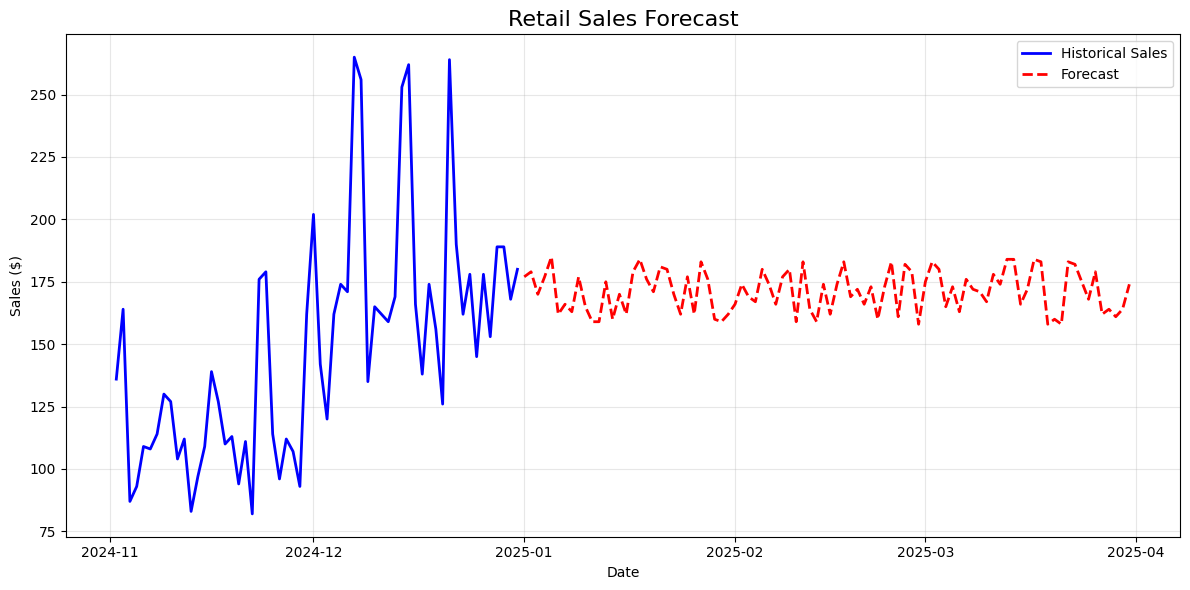


✅ Forecast complete!


In [15]:
# ============================================
# RETAIL DEMAND FORECASTER - Google Colab Version
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt

print("🏪 RETAIL DEMAND FORECASTER")
print("=" * 50)

# Step 1: Create sample sales data
def create_sample_data():
    """Generate 2 years of sample retail sales data"""
    dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')

    sales = []
    for date in dates:
        weekday = date.weekday()
        # Weekend sales are higher
        if weekday >= 5:  # Saturday or Sunday
            base = 150 + random.randint(-30, 30)
        else:
            base = 100 + random.randint(-20, 20)

        # Seasonal patterns
        month = date.month
        if month in [6, 7, 8]:  # Summer
            base = base * 1.3
        elif month == 12:  # December (holiday)
            base = base * 1.5

        sales.append(max(0, int(base)))

    data = pd.DataFrame({
        'date': dates,
        'sales': sales,
        'store_id': np.random.randint(1, 6, len(dates))
    })
    return data

# Step 2: Simple forecasting
def simple_forecast(data, days_ahead):
    """Predict future sales using moving average"""
    # Use last 7 days average as baseline
    last_week_avg = data.tail(7)['sales'].mean()

    last_date = data['date'].max()
    forecast_dates = [last_date + timedelta(days=i) for i in range(1, days_ahead+1)]

    forecasts = []
    for i in range(days_ahead):
        # Add small random variation
        forecast_value = last_week_avg * (1 + random.uniform(-0.08, 0.08))
        forecasts.append(max(0, int(forecast_value)))

    forecast_df = pd.DataFrame({
        'date': forecast_dates,
        'predicted_sales': forecasts
    })
    return forecast_df

# ============================================
# MAIN PROGRAM
# ============================================

# Generate data
data = create_sample_data()
print(f"✅ Loaded {len(data)} days of sales data")
print(f"   Date range: {data['date'].min().strftime('%Y-%m-%d')} to {data['date'].max().strftime('%Y-%m-%d')}")
print(f"   Average daily sales: ${data['sales'].mean():.0f}")
print(f"   Total stores: {data['store_id'].nunique()}")

# Ask user for forecast period
print("\n📊 SELECT FORECAST PERIOD:")
print("1) 7 days (1 week)")
print("2) 30 days (1 month)")
print("3) 90 days (3 months)")

choice = input("Enter your choice (1, 2, or 3): ")

if choice == "1":
    days_ahead = 7
elif choice == "2":
    days_ahead = 30
elif choice == "3":
    days_ahead = 90
else:
    days_ahead = 30
    print(f"\n⚠️ Invalid choice. Using default: {days_ahead} days")

# Generate forecast
forecast = simple_forecast(data, days_ahead)

# Display forecast
print(f"\n📈 FORECAST FOR NEXT {days_ahead} DAYS:")
print("=" * 55)
for idx, row in forecast.head(10).iterrows():
    print(f"   {row['date'].strftime('%Y-%m-%d')}: ${row['predicted_sales']}")

if days_ahead > 10:
    print(f"   ... and {days_ahead - 10} more days")

# Summary statistics
avg_forecast = forecast['predicted_sales'].mean()
total_forecast = forecast['predicted_sales'].sum()

print("\n💡 SUMMARY:")
print(f"   Average predicted daily sales: ${avg_forecast:.0f}")
print(f"   Total predicted sales: ${total_forecast:.0f}")

# Visualize the data (optional but impressive!)
print("\n📊 Generating visualization...")

plt.figure(figsize=(12, 6))

# Plot historical sales (last 60 days)
historical = data.tail(60)
plt.plot(historical['date'], historical['sales'],
         label='Historical Sales', color='blue', linewidth=2)

# Plot forecast
plt.plot(forecast['date'], forecast['predicted_sales'],
         label='Forecast', color='red', linestyle='--', linewidth=2)

plt.title('Retail Sales Forecast', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Forecast complete!")